# 12 - `generative_regime`: a regime-resolved score prior

3DVar's background is a single Gaussian: the field looks like the climatology give or take
one fixed pattern of wobble `B`, and how far the analysis slides toward the proxies is
decided by that same `B` whatever the proxies say. The leading principal components of the
LOVECLIM states are not unimodal, so that is the wrong shape.

This prior says instead that the field looks like one of a handful of climate regimes, each
with its own typical map and its own pattern of wobble. The proxies then do two jobs: work
out which regime the field is in, and refine within it.

The construction follows from there.

1. Cluster the prior states on their leading principal scores, the subspace the bimodality
   sits in, and fit a Gaussian to each cluster.
2. A Gaussian mixture convolved with Gaussian noise is still a Gaussian mixture, so the EDM
   denoiser is closed form at every noise level.
3. A Gaussian mixture under a linear-Gaussian likelihood has a Gaussian-mixture posterior,
   so the analysis is closed form outright: one Kalman update per component, reweighted by
   each component's marginal likelihood.
4. At one regime the mixture is `N(0, kB)`, which is 3DVar at amplitude `k`. The baseline is
   nested exactly, so anything above it is attributable to the regime structure.
5. A tempered, zero-initialised learned residual sits on the mixture denoiser, so the
   network only ever corrects a prior that is already right.

Because the score is closed form, the posterior can be reached two ways: `exact`, the
closed-form mixture posterior, and `guided`, the EDM reverse process. At `temper = 0` they
target the same distribution, so their difference measures the inference error alone.

Artefacts land in `outputs/da/generative_regime/`, so notebook 09 picks the method up
through its existing glob. **Run notebook 07 first**: the background, its taper and its
band-pass window are all read from that lane's selected config.

In [1]:
%load_ext autoreload
%autoreload 2

import json
import os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[_v] = "1"

import sys
import time
from contextlib import contextmanager
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

sys.path.insert(0, os.path.abspath(".."))

from paleoreco.data import build_prior_cube, VARS
from paleoreco.data.cube import apply_anomaly, compute_zscore_stats, highpass_states
from paleoreco.data.splits import chronological_half_split
from paleoreco.assim.observations import (
    attach_site_stats, collapse_to_samples, load_observations, observation_site_stats,
)
from paleoreco.assim.priors import build_prior, regularization_mask
from paleoreco.assim.regimes import (
    build_regime_mixture, exact_posterior, exact_posterior_mean_sweep, partition_states,
)
from paleoreco.assim.regime_sampler import RegimeSampler
from paleoreco.models.regime_score import build_regime_denoiser, load_regime_denoiser
from paleoreco.training import trainer_diffusion as td
from paleoreco.assim import experiments_generative as gex
from paleoreco.eval import da

plt.rcParams["figure.dpi"] = 110
DATA = "../data"
OUT = Path("../outputs/da")
CKPT = Path("../outputs/checkpoints/12_generative_regime")
FIG = Path("../outputs/figures/12_generative_regime")
CKPT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

LANES = ("ppe", )                       # add "withholding" once notebook 07 has run it
LANE_PRIOR = {"ppe": "chunkA", "withholding": "full"}
LANE_NAME = {"ppe": "ppe", "withholding": "withholding_random"}
TRUTH_STRIDE = 10
FOLD_KIND, AGE_STRIDE = "random", 6

# --- stage 1: the partition grid, scored on the closed-form arm ----------------
# ``time`` is the control rather than a candidate: it cuts the prior into contiguous age
# windows, so if it scored like the state-space rules the effect would be epochs and not
# regimes. It is in the grid so that claim is re-measured every run.
REGIME_RULES = ("kmeans", "time")
J_GRID = (1, 2, 3, 4)
RHO_GRID = (0.3, 0.6)                   # rho = 0 is excluded: a regime holds ~100-200 states
B_SCALES = (0.5, 1.0, 2.0, 5.0, 10.0)

# --- stage 2: the learned residual and the guided lane -------------------------
TEMPER_GRID = gex.REGIME_TEMPER_GRID    # (0, 0.25, 0.5, 1.0); 0 is the closed-form floor
K, K_SELECT = 256, 16
N_STEPS, MAX_BATCH, N_PRIOR_VAR = 64, 64, 512
RETRAIN = True
EPOCHS, BASE, DEPTH, LR, BATCH = 3000, 64, 2, 2e-4, 64
VAL_FRACTION, PATIENCE, SPLIT_SEED = 0.25, 50, 0
# The EDM defaults (-1.2, 1.2) are calibrated for unit-variance images and put 99% of
# their mass below sigma 4.9, while this field's leading modes sit at sigma 10-21 - the
# mismatch measured as the pixel prior's central failure. The mixture is exact at every
# noise level so it does not care, but the residual is trained here, so its noise
# distribution is widened to span the prior's own spectrum. The build below prints the
# spectrum against these numbers so the choice is checkable rather than asserted.
P_MEAN, P_STD = 0.2, 1.4

print("device:", DEVICE, "| lanes:", LANES)

/vol/bitbucket/egg25/diss/sparse_paleoclimate_field_reconstruction/paleo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda | lanes: ('ppe',)


## The prior states, and the background this method must beat

Everything is read from notebook 07's selected config for the lane, so the regime
components are tapered with the same Schur mask the baseline's `B` carries and built from
the same band-passed states. That is what makes the comparison attributable: at one regime
this prior *is* that `B`, so any difference comes from the regimes and not from a quietly
different Gaussian.

In [2]:
P = build_prior_cube(prior_csv=f"{DATA}/Prior.csv", cache_path=f"{DATA}/cache/prior_cube.npz")
cube, ages, lats, lons, valid = P["cube"], P["ages"], P["lats"], P["lons"], P["valid"]
SHAPE = (len(VARS), *cube.shape[2:])
all_idx = np.arange(len(ages))
prior_idx, truth_idx = chronological_half_split(ages, stride=TRUTH_STRIDE)
PRIOR_IDX = {"chunkA": prior_idx, "full": all_idx}

long_ppe = load_observations(f"{DATA}/Observation.csv")
long_wh = attach_site_stats(long_ppe, observation_site_stats(collapse_to_samples(long_ppe)))


def selected_config(lane):
    """Notebook 07's tuned background for ``lane``. This notebook has no opinion of its own."""
    path = OUT / "3dvar_pixel" / f"{LANE_NAME[lane]}_config.json"
    if not path.exists():
        raise FileNotFoundError(
            f"{path} is missing - run notebook 07's {lane} lane first. This notebook "
            f"inherits its taper and band-pass window so the comparison is like for like.")
    sel = json.load(open(path))["selected"]
    return {k: sel[k] for k in ("localization_km", "shrinkage_lambda", "alpha",
                                "highpass_window")}


TAPER = {lane: selected_config(lane) for lane in LANES}
FRAME = {}
for lane in LANES:
    name, t = LANE_PRIOR[lane], TAPER[lane]
    idx = PRIOR_IDX[name]
    stats = compute_zscore_stats(cube, idx, valid)
    states = highpass_states(apply_anomaly(cube, stats)[idx].reshape(len(idx), -1),
                             np.asarray(ages)[idx], t["highpass_window"])
    mask = regularization_mask(lats, lons, localization_km=t["localization_km"],
                               shrinkage_lambda=t["shrinkage_lambda"], alpha=t["alpha"])
    B = build_prior(cube, ages, lats, lons, idx, valid, **t).B
    FRAME[name] = dict(states=states, safe=stats["safe_valid"], mask=mask, B=B,
                       ages=np.asarray(ages)[idx], taper=t)
    ev = np.linalg.eigvalsh(B)[::-1]
    share4 = ev[:4].sum() / ev.sum()
    print(f"[{lane}] {len(states)} states | background {t}")
    print(f"        leading sqrt(eigenvalue) {np.round(np.sqrt(ev[:4]), 1)} "
          f"({share4:.0%} of the variance)")
    print(f"        residual training noise spans e^({P_MEAN}+-2*{P_STD}) = "
          f"[{np.exp(P_MEAN - 2*P_STD):.2f}, {np.exp(P_MEAN + 2*P_STD):.1f}] "
          f"- the leading modes have to fall inside it")

[ppe] 402 states | background {'localization_km': 15000.0, 'shrinkage_lambda': 0.0, 'alpha': 0.5, 'highpass_window': 6000.0}
        leading sqrt(eigenvalue) [54.8 27.6 17.9 13.3] (82% of the variance)
        residual training noise spans e^(0.2+-2*1.4) = [0.07, 20.1] - the leading modes have to fall inside it


## Stage 1 - which partition, on the closed-form arm

The mixture's posterior is available in closed form, so the partition can be chosen without
sampling anything: for each `(rule, J, rho)` the analysis is one Kalman update per component
with the weights set by each component's marginal likelihood. That is about a minute per
configuration against many for a guided pass, which is why the partition is settled here and
only the temper is swept by the sampler afterwards.

**Read the selection split only.** The four in-rotation network shapes decide; the held-out
shape is untouched until the lane runs. `J = 1` sits in the grid as the exact 3DVar control.

Each configuration prints its regime sizes and the separation between component means in
units of the pooled spread. A mixture whose components sit on top of each other has nothing
to offer, and that shows up here before any skill number does. The `control` rows are the
time-window partition: if they score like the state-space rule, the split does not need to
be in state space and the regime reading does not hold.

In [3]:
LANE = LANES[0]
NAME = LANE_PRIOR[LANE]
F = FRAME[NAME]
long_lane = long_ppe if LANE == "ppe" else long_wh

# Stage 1 picks (J, rho) on a pseudo-proxy construction whichever lane is being run,
# because choosing a partition needs a known field to score against and the withholding
# lane's truth is a point measurement. On the withholding lane read the absolute numbers
# below with that in mind: its prior is the whole record, so the states being scored are
# inside it and the level is optimistic. The *ordering* over (J, rho) is what stage 1 is
# for, and stage 2 then selects temper and b_scale on that lane's own held-out sites.

S = gex._ppe_setup(cube, ages, lats, lons, valid, long_lane, n_shapes=5, n_noise=5,
                   truth_stride=TRUTH_STRIDE, seed=0,
                   highpass_window=F["taper"]["highpass_window"])
truth, T = S["truth_anoms"], S["T"]
SEL_SHAPES, TEST_SHAPE = range(4), 4
sel_cases = [(ti, *S["obs"](ti, si)) for si in SEL_SHAPES for ti in range(T)]
sel_truth_sse = np.array([float((truth[ti][:, F["safe"]] ** 2).sum())
                          for ti, _, _ in sel_cases])


def selection_rrmse(mix):
    """Pooled RRMSE on the selection shapes, per b_scale. No sampling, no truth leakage."""
    sse = np.zeros((len(B_SCALES), len(sel_cases)))
    for i, (ti, geom, y) in enumerate(sel_cases):
        means = exact_posterior_mean_sweep(mix, geom["gather"], geom["sse"], y, B_SCALES)
        for bi in range(len(B_SCALES)):
            d = (truth[ti] - means[bi].reshape(SHAPE))[:, F["safe"]]
            sse[bi, i] = float((d ** 2).sum())
    return np.sqrt(sse.sum(axis=1) / sel_truth_sse.sum())


t0 = time.time()
rows = []
for rule in REGIME_RULES:
    for J in J_GRID:
        for rho in RHO_GRID:
            if J == 1 and (rho != RHO_GRID[0] or rule != REGIME_RULES[0]):
                continue                      # one regime ignores both knobs
            lab = partition_states(F["states"], J, rule=rule, ages=F["ages"], seed=0)
            mix = build_regime_mixture(F["states"], lab, SHAPE, F["safe"], mask=F["mask"],
                                       rho=1.0 if J == 1 else rho,
                                       meta={"rule": rule})
            rr = selection_rrmse(mix)
            bi = int(np.argmin(rr))
            rows.append({"rule": "control" if rule == "time" else rule,
                         "J": J, "rho": rho if J > 1 else np.nan,
                         "b_scale": B_SCALES[bi], "sel_rrmse": rr[bi],
                         "sizes": str(mix.meta["sizes"]),
                         "separation": mix.meta["mean_separation"]})
            print(f"  {rule:7s} J={J} rho={rho:.1f}: sel rRMSE {rr[bi]:.4f} at b={B_SCALES[bi]:g}"
                  f" | sizes {mix.meta['sizes']} sep {mix.meta['mean_separation']:.2f}"
                  f" [{time.time()-t0:.0f}s]", flush=True)

grid = pd.DataFrame(rows).sort_values("sel_rrmse").reset_index(drop=True)
display(grid.round(4))

# The winner among the state-space rules; the time control is scored but never selected.
cand = grid[grid.rule != "control"]
best = cand.iloc[0]
J_STAR, RHO_STAR = int(best["J"]), (1.0 if best["J"] == 1 else float(best["rho"]))
base_row = grid[(grid.J == 1)].iloc[0]
print(f"\nselected: J={J_STAR}, rho={RHO_STAR} "
      f"(selection rRMSE {best['sel_rrmse']:.4f} against {base_row['sel_rrmse']:.4f} at J=1)")
print(f"time-window control best: {grid[grid.rule == 'control']['sel_rrmse'].min():.4f} "
      f"- if this matches the state-space rules, the effect is epochs, not regimes")
if J_STAR == 1:
    print("\n!! the selection split chose one regime: on this lane the prior has declined\n"
          "   to be a mixture, and the run below is 3DVar. Report that, do not bury it.")

  kmeans  J=1 rho=0.3: sel rRMSE 0.5048 at b=5 | sizes [402] sep 0.00 [18s]
  kmeans  J=2 rho=0.3: sel rRMSE 0.5048 at b=5 | sizes [227, 175] sep 1.67 [55s]
  kmeans  J=2 rho=0.6: sel rRMSE 0.5032 at b=5 | sizes [227, 175] sep 1.67 [95s]
  kmeans  J=3 rho=0.3: sel rRMSE 0.4952 at b=5 | sizes [208, 88, 106] sep 2.11 [150s]
  kmeans  J=3 rho=0.6: sel rRMSE 0.4983 at b=5 | sizes [208, 88, 106] sep 2.11 [206s]
  kmeans  J=4 rho=0.3: sel rRMSE 0.4976 at b=5 | sizes [138, 88, 72, 104] sep 2.31 [279s]
  kmeans  J=4 rho=0.6: sel rRMSE 0.4990 at b=5 | sizes [138, 88, 72, 104] sep 2.31 [353s]
  time    J=2 rho=0.3: sel rRMSE 0.5042 at b=5 | sizes [201, 201] sep 0.28 [391s]
  time    J=2 rho=0.6: sel rRMSE 0.5032 at b=5 | sizes [201, 201] sep 0.28 [430s]
  time    J=3 rho=0.3: sel rRMSE 0.5083 at b=5 | sizes [134, 134, 134] sep 0.40 [486s]
  time    J=3 rho=0.6: sel rRMSE 0.5045 at b=5 | sizes [134, 134, 134] sep 0.40 [545s]
  time    J=4 rho=0.3: sel rRMSE 0.5139 at b=5 | sizes [101, 100, 100, 1

,rule,J,rho,b_scale,sel_rrmse,sizes,separation
0,kmeans,3,0.3,5.0,0.4952,"[208, 88, 106]",2.1063
1,kmeans,4,0.3,5.0,0.4976,"[138, 88, 72, 104]",2.3090
2,kmeans,3,0.6,5.0,0.4983,"[208, 88, 106]",2.1063
3,kmeans,4,0.6,5.0,0.4990,"[138, 88, 72, 104]",2.3090
4,kmeans,2,0.6,5.0,0.5032,"[227, 175]",1.6692
5,control,2,0.6,5.0,0.5032,"[201, 201]",0.2844
6,control,2,0.3,5.0,0.5042,"[201, 201]",0.2844
7,control,3,0.6,5.0,0.5045,"[134, 134, 134]",0.3962
8,kmeans,1,NaN,5.0,0.5048,[402],0.0000
9,kmeans,2,0.3,5.0,0.5048,"[227, 175]",1.6692



selected: J=3, rho=0.3 (selection rRMSE 0.4952 against 0.5048 at J=1)
time-window control best: 0.5032 - if this matches the state-space rules, the effect is epochs, not regimes


## Verification: is the sampler the approximation?

Three gates on the real background, run before any skill number is read. The unit tests pin
the same properties on small synthetic covariances; these run them at full dimension, where
the taper is not positive definite and the spectrum is wide.

1. **One regime is 3DVar.** The closed-form posterior at `J = 1` must reproduce the gain
   form. Any residue is the positive-definite projection of the tapered covariance, printed
   alongside. If this fails, the Gaussian part of the prior is wrong.
2. **The reverse process is not the approximation.** The same prior sampled by guided
   diffusion must reproduce 3DVar too, now within Monte Carlo error. This gates the ODE and
   the guidance separately from the prior.
3. **The two arms agree at the selected partition.** Exact and guided target the same
   distribution when the residual is off, so their gap is the inference error and nothing
   else. The spread ratio catches variance collapse, which comparing means would miss.

If gate 3 shows the guided arm off by an appreciable fraction of a posterior standard
deviation, it is spending the gain on its own sampling error and the exact arm is the
honest headline.

In [4]:
from scipy.linalg import cho_factor, cho_solve

_geom, _y = S["obs"](0, TEST_SHAPE)
_g, _r = _geom["gather"], _geom["sse"]
_b = float(best["b_scale"])


def mc_units(ens, ref, sd):
    """RMS difference from ``ref`` in units of the ensemble's own Monte Carlo floor.

    ~1 when two ensembles differ only by sampling noise, and growing as sqrt(n) under a
    real bias, so re-running with more draws tells the two apart. ``max |mean - ref|``
    cannot: over four thousand cells it is dominated by the maximum of that many
    near-Gaussian errors whether or not there is any bias to find.
    """
    err = np.sqrt(np.mean((ens.mean(0) - ref) ** 2))
    return err / (np.sqrt(np.mean(sd ** 2)) / np.sqrt(len(ens)))


# --- gate 1: one regime is exactly 3DVar --------------------------------------
mix1 = build_regime_mixture(F["states"], partition_states(F["states"], 1), SHAPE,
                            F["safe"], mask=F["mask"], rho=1.0)
_ch = cho_factor(_b * F["B"][np.ix_(_g, _g)] + np.diag(_r))
raw = _b * (F["B"][:, _g] @ cho_solve(_ch, _y))
ex1 = RegimeSampler(mix1, b_scale=_b, inference="exact", device="cpu")
got = ex1.exact_mean(_g, _r, _y).ravel()
print(f"gate 1  one regime vs the 3DVar gain form: {np.abs(got - raw).max():.4f} degC, "
      f"relative {np.abs(got - raw).max() / np.abs(raw).max():.1e}")
print(f"        (the residue is the positive-definite projection of the tapered "
      f"covariance: {mix1.meta['n_negative_clipped']} negative eigenvalues, floored at "
      f"{mix1.meta['eig_floor']:.0e} of the largest)")

# --- gate 2: the guided reverse process reproduces the same prior -------------
sd1 = ex1.sample_posterior(_g, _y, _r, _b, 2048, seed=1).reshape(2048, -1).std(0)
gu1 = RegimeSampler(mix1, b_scale=_b, inference="guided", n_steps=N_STEPS,
                    max_batch=MAX_BATCH, device=DEVICE)
e1 = gu1.sample_posterior(_g, _y, _r, _b, 512, seed=1).reshape(512, -1)
print(f"gate 2  guided vs the exact arm, one regime: {mc_units(e1, got, sd1):.2f} MC units"
      f" (1 is the sampling floor) | schedule tops out at sigma {gu1.sigmas[0]:.0f} against "
      f"a leading mode of {np.sqrt(_b * mix1.lam.max()):.0f}")

# --- gate 3: exact against guided at the selected partition -------------------
MIX = build_regime_mixture(
    F["states"], partition_states(F["states"], J_STAR, ages=F["ages"], seed=0), SHAPE,
    F["safe"], mask=F["mask"], rho=RHO_STAR,
    meta={"lane": LANE, "rule": "kmeans", **F["taper"]})
print(f"        mixture: sizes {MIX.meta['sizes']} | weights "
      f"{np.round(MIX.meta['weights'], 3)} | separation {MIX.meta['mean_separation']:.2f}"
      f" | condition {np.max(MIX.meta['conditions']):.1e}")

ex = RegimeSampler(MIX, b_scale=_b, inference="exact", device="cpu")
gu = RegimeSampler(MIX, b_scale=_b, inference="guided", n_steps=N_STEPS,
                   max_batch=MAX_BATCH, device=DEVICE)
ref_mix = ex.exact_mean(_g, _r, _y, _b).ravel()
ee = ex.sample_posterior(_g, _y, _r, _b, 2048, seed=2).reshape(2048, -1)
eg = gu.sample_posterior(_g, _y, _r, _b, 512, seed=2).reshape(512, -1)
sd = ee.std(0)
print(f"gate 3  exact ensemble  vs closed form: {mc_units(ee, ref_mix, sd):.2f} MC units")
print(f"        guided         vs closed form: {mc_units(eg, ref_mix, sd):.2f} MC units"
      f" | spread ratio {(eg.std(0)/sd).mean():.3f} | dtype {gu.dtype} on {gu.device}")
assert np.abs(got - raw).max() / np.abs(raw).max() < 1e-2, \
    "one regime is not 3DVar; the Gaussian part of the prior is wrong"

gate 1  one regime vs the 3DVar gain form: 0.0217 degC, relative 3.6e-03
        (the residue is the positive-definite projection of the tapered covariance: 1563 negative eigenvalues, floored at 1e-06 of the largest)
gate 2  guided vs the exact arm, one regime: 1.12 MC units (1 is the sampling floor) | schedule tops out at sigma 981 against a leading mode of 123
        mixture: sizes [208, 88, 106] | weights [0.517 0.219 0.264] | separation 2.11 | condition 1.0e+06
gate 3  exact ensemble  vs closed form: 0.95 MC units
        guided         vs closed form: 0.88 MC units | spread ratio 1.000 | dtype torch.float32 on cuda


## The learned residual

The mixture already carries the covariance exactly, so the network is not asked to be the
prior. It is asked for a correction to one:

    D(x; σ) = D_mixture(x; σ) + t · c_out(σ) · F(c_in(σ) x; c_noise(σ))

with `F`'s output layer zero-initialised, so an untrained network reproduces the mixture
denoiser identically. Training is ordinary EDM denoising score matching against the same
band-passed states; because the mixture term is fixed and known, what the network learns is
the departure from it. That is the residual-from-the-mean decomposition applied to the
score.

A closed-form score is exact at every noise level, but a trained one is only as good as the
noise levels it saw. The training distribution is therefore widened from the EDM image
defaults to span this field's own spectrum (`P_MEAN`, `P_STD` above, printed against the
leading modes in the build cell).

The temper `t` is selected on held-out data with `0` in the grid, so the residual is used
only if it earns its place. Set `RETRAIN = False` once the checkpoint exists.

In [5]:
def regime_provenance():
    """Plain scalars identifying the prior a checkpoint's residual was trained against.

    The mixture is rebuilt from the prior states rather than stored in the checkpoint, so
    a residual trained against another partition, shrinkage, taper or band-pass window
    would otherwise load silently against the wrong prior and produce quietly wrong fields.
    """
    t = F["taper"]
    return {"regime_j": int(J_STAR), "regime_rho": float(RHO_STAR),
            "regime_prior": str(NAME),
            "regime_localization_km": float(t["localization_km"] or -1.0),
            "regime_shrinkage_lambda": float(t["shrinkage_lambda"]),
            "regime_alpha": float(t["alpha"]),
            "regime_highpass": float(t["highpass_window"] or -1.0),
            "p_mean": float(P_MEAN), "p_std": float(P_STD)}


CKPT_PATH = CKPT / f"regime_{NAME}_J{J_STAR}.pt"
PROV = regime_provenance()


def _net_cfg():
    return {"base_channels": BASE, "depth": DEPTH, "grid_shape": tuple(cube.shape[2:])}


def train_residual():
    """Select the epoch count on a held-out split, then refit on every state."""
    if CKPT_PATH.exists() and not RETRAIN:
        ck = torch.load(CKPT_PATH, map_location="cpu")
        if all(ck.get(k) == v for k, v in PROV.items()):
            print("exists:", CKPT_PATH.name)
            return None
        print(f"{CKPT_PATH.name} was trained against another prior; retraining", flush=True)

    data = F["states"].reshape(len(F["states"]), *SHAPE).astype(np.float32)
    perm = np.random.default_rng(SPLIT_SEED).permutation(len(data))
    n_val = int(round(VAL_FRACTION * len(data)))
    val_idx, train_idx = perm[:n_val], perm[n_val:]

    print(f"search | {len(train_idx)} train / {len(val_idx)} val | max {EPOCHS} ep, "
          f"patience {PATIENCE}", flush=True)
    t = time.time()
    search = td.train(build_regime_denoiser(MIX, _net_cfg()), data[train_idx], F["safe"],
                      val_cube=data[val_idx], patience=PATIENCE, max_epochs=EPOCHS,
                      batch_size=BATCH, lr=LR, device=DEVICE, p_mean=P_MEAN, p_std=P_STD,
                      seed=0)
    n_star = search["best_epoch"] + 1
    print(f"search | done in {time.time()-t:.0f}s | best ep {search['best_epoch']} | "
          f"stopped at {search['stop_epoch']} | early={search['stopped_early']} | "
          f"refit to {n_star}", flush=True)

    t = time.time()
    td.train(build_regime_denoiser(MIX, _net_cfg()), data, F["safe"], max_epochs=n_star,
             lr_schedule_epochs=EPOCHS, batch_size=BATCH, lr=LR, device=DEVICE,
             p_mean=P_MEAN, p_std=P_STD, checkpoint_path=str(CKPT_PATH), seed=0,
             checkpoint_extra={**PROV, "refit_epochs": int(n_star),
                               "stopped_early": bool(search["stopped_early"])})
    print(f"refit  | done in {time.time()-t:.0f}s | wrote {CKPT_PATH.name}", flush=True)
    np.savez(CKPT / f"{CKPT_PATH.stem}_search.npz",
             **{k: np.asarray(v) for k, v in search["history"].items()})
    return search


SEARCH = train_residual()
RESIDUAL, _ck = load_regime_denoiser(str(CKPT_PATH), MIX)
_x = torch.as_tensor(F["states"][:2].reshape(2, *SHAPE), dtype=torch.float32)
_zero = RESIDUAL.at_temper(0.0)
print(f"residual loaded | temper 0 reproduces the mixture: "
      f"{torch.allclose(_zero(_x, 0.7), RESIDUAL.mixture(_x, 0.7), atol=1e-6)}")
print(f"                | at temper 1 it moves the denoiser by "
      f"{(RESIDUAL(_x, 0.7) - RESIDUAL.mixture(_x, 0.7)).abs().max().item():.4f} degC at sigma 0.7")

search | 302 train / 100 val | max 3000 ep, patience 50


diffusion:   0%|          | 1/3000 [00:01<56:26,  1.13s/ep, loss=0.2626, val=0.1817, best=0.1817, wait=0, s/ep=1.1]

epoch    0  loss=0.2626  val=0.1817  best=0.1817@0  lr=2.00e-04  (1.1s)


diffusion:   2%|▏         | 51/3000 [00:24<23:57,  2.05ep/s, loss=0.2402, val=0.1803, best=0.1803, wait=0, s/ep=0.5]

epoch   50  loss=0.2402  val=0.1803  best=0.1803@50  lr=2.00e-04  (0.5s)


...

epoch 1200  loss=0.2262  lr=1.31e-04  (0.3s)


diffusion:  97%|█████████▋| 1251/1295 [05:23<00:11,  3.85ep/s, loss=0.2079, s/ep=0.3]

epoch 1250  loss=0.2079  lr=1.26e-04  (0.3s)


diffusion: 100%|██████████| 1295/1295 [05:35<00:00,  3.87ep/s, loss=0.2056, s/ep=0.3]


refit  | done in 336s | wrote regime_chunkA_J3.pt
residual loaded | temper 0 reproduces the mixture: True
                | at temper 1 it moves the denoiser by 0.0639 degC at sigma 0.7


## Stage 2 - the lane

The runner sweeps the temper and the background amplitude jointly on the selection split at
the partition stage 1 chose, then runs the winner once on the disjoint test shape. Rows carry
`method="generative_regime"` with `regime_j`, `regime_rho` and `regime_temper` columns, so
notebook 09 reports the method at its own selected operating point through the same
machinery every other method uses.

`temper = 0` is in the grid, and it is the closed-form mixture. **Read the selected temper
off the config when the run finishes.** If it is zero, the learned residual did not earn its
place on held-out data and the method is the mixture prior alone, which the write-up should
say rather than imply a network is doing work it is not.

In [6]:
d_reg = OUT / "generative_regime"
t_lane = time.time()

MIX_CACHE = {(J_STAR, RHO_STAR): MIX}


@contextmanager
def make_sampler(n_regimes, rho, temper):
    """One sampler per (J, rho, temper); the mixture is built once and reused."""
    key = (int(n_regimes), float(rho))
    if key not in MIX_CACHE:
        lab = partition_states(F["states"], n_regimes, ages=F["ages"], seed=0)
        MIX_CACHE[key] = build_regime_mixture(
            F["states"], lab, SHAPE, F["safe"], mask=F["mask"],
            rho=1.0 if n_regimes == 1 else rho,
            meta={"lane": LANE, "rule": "kmeans", **F["taper"]})
    mix = MIX_CACHE[key]
    residual = RESIDUAL if temper > 0 else None
    yield RegimeSampler(mix, residual, b_scale=1.0, temper=float(temper),
                        inference="exact" if temper == 0 else "guided",
                        n_samples=K, n_steps=N_STEPS, max_batch=MAX_BATCH, device=DEVICE)


for lane in LANES:
    gex.clear_lane(str(d_reg), LANE_NAME[lane])
    print(f"[{lane} regime] J={J_STAR} rho={RHO_STAR}, tempers {TEMPER_GRID}", flush=True)
    if lane == "ppe":
        gex.run_ppe_generative_regime(
            cube, ages, lats, lons, valid, long_ppe, str(d_reg),
            make_sampler=make_sampler, regime_grid=((J_STAR, RHO_STAR),),
            temper_grid=TEMPER_GRID, gamma_grid=B_SCALES, n_samples=K,
            n_samples_select=K_SELECT, truth_stride=TRUTH_STRIDE,
            n_prior_var=N_PRIOR_VAR, highpass_window=F["taper"]["highpass_window"],
            progress_every=50)
    else:
        gex.run_withholding_generative_regime(
            cube, ages, lats, lons, valid, long_wh, str(d_reg),
            make_sampler=make_sampler, regime_grid=((J_STAR, RHO_STAR),),
            temper_grid=TEMPER_GRID, gamma_grid=B_SCALES, n_samples=K,
            n_samples_select=K_SELECT, fold_kind=FOLD_KIND, age_stride=AGE_STRIDE,
            highpass_window=F["taper"]["highpass_window"], progress_every=50)

print(f"{len(LANES)} lane(s) in {time.time() - t_lane:.0f}s")
CFG = json.load(open(d_reg / f"{LANE_NAME[LANE]}_config.json"))
print("selected:", CFG["selected"])
if CFG["selected"]["regime_temper"] == 0.0:
    print("\n!! temper 0 was selected: the learned residual did not earn its place on the\n"
          "   selection split. The method is the closed-form mixture prior - which still\n"
          "   beats 3DVar - but the network contributes nothing and the write-up must say so.")

[ppe regime] J=3 rho=0.3, tempers (0.0, 0.25, 0.5, 1.0)
  regime selection draws (J=3, rho=0.3, t=0) 50/240 (21%, elapsed 2s, eta 9s)
  regime selection draws (J=3, rho=0.3, t=0) 100/240 (42%, elapsed 5s, eta 7s)
  regime selection draws (J=3, rho=0.3, t=0) 150/240 (62%, elapsed 7s, eta 4s)
  regime selection draws (J=3, rho=0.3, t=0) 200/240 (83%, elapsed 10s, eta 2s)
  regime selection draws (J=3, rho=0.3, t=0.25) 50/240 (21%, elapsed 50s, eta 190s)
  regime selection draws (J=3, rho=0.3, t=0.25) 100/240 (42%, elapsed 100s, eta 140s)
  regime selection draws (J=3, rho=0.3, t=0.25) 150/240 (62%, elapsed 150s, eta 90s)
  regime selection draws (J=3, rho=0.3, t=0.25) 200/240 (83%, elapsed 200s, eta 40s)
  regime selection draws (J=3, rho=0.3, t=0.5) 50/240 (21%, elapsed 50s, eta 190s)
  regime selection draws (J=3, rho=0.3, t=0.5) 100/240 (42%, elapsed 100s, eta 140s)
  regime selection draws (J=3, rho=0.3, t=0.5) 150/240 (62%, elapsed 150s, eta 90s)
  regime selection draws (J=3, rho=0

### Where it landed

The test-split row against the baseline this method inherits its background from. CE, RMSE,
rRMSE and SSIM all score against a zero-anomaly climatology, so they are directly
comparable with notebook 07's numbers; CRPSS is not, because its reference is each run's
own `diag(B)`.

,pixel 3DVar,generative_regime,delta
metric,,,
ce,0.7433,0.7478,0.0045
rmse,0.5868,0.5816,-0.0052
rrmse,0.5066,0.5022,-0.0045
ssim,0.6991,0.7062,0.0072
corr,0.8622,0.8650,0.0027
amplitude,0.8715,0.8594,-0.0121
crps,0.2825,0.2738,-0.0086
coverage90,0.9811,0.9774,-0.0037
rcrv_dispersion,0.6810,0.7042,0.0231



CE 0.7433 -> 0.7478  (+0.0045)


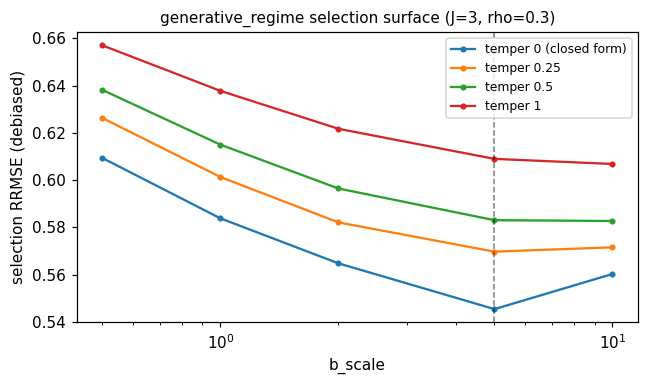

In [7]:
M = pd.read_csv(d_reg / "metrics.csv")
sel = CFG["selected"]
row = M[(M.method == "generative_regime") & (M.split == "test") & (M.channel == "pooled")
        & (M.do_event == "all")]
for k in ("regime_j", "regime_rho", "regime_temper", "b_scale"):
    row = row[np.isclose(row[k].astype(float), float(sel[k]))]
mine = row.set_index("metric")["value"]

base = pd.read_csv(OUT / "3dvar_pixel" / "metrics.csv")
bsel = json.load(open(OUT / "3dvar_pixel" / "ppe_config.json"))["selected"]
base = base[(base.method == "3dvar") & (base.split == "test") & (base.channel == "pooled")
            & (base.do_event == "all")]
for k, v in bsel.items():
    if k in base.columns:
        col = base[k].astype(float)
        base = base[col.isna() if v is None else np.isclose(col, float(v))]
theirs = base.set_index("metric")["value"]

METRICS = ["ce", "rmse", "rrmse", "ssim", "corr", "amplitude", "crps", "coverage90",
           "rcrv_dispersion"]
cmp = pd.DataFrame({"pixel 3DVar": theirs.reindex(METRICS),
                    "generative_regime": mine.reindex(METRICS)})
cmp["delta"] = cmp["generative_regime"] - cmp["pixel 3DVar"]
display(cmp.round(4))
print(f"\nCE {theirs.get('ce', float('nan')):.4f} -> {mine.get('ce', float('nan')):.4f}"
      f"  ({mine.get('ce', float('nan')) - theirs.get('ce', float('nan')):+.4f})")

# The selection surface the operating point was actually chosen on.
s = M[(M.split == "selection") & (M.channel == "pooled") & (M.do_event == "all")
      & (M.metric == "rrmse_ens")]
fig, ax = plt.subplots(figsize=(6, 3.6))
for t, grp in s.groupby("regime_temper"):
    grp = grp.sort_values("b_scale")
    ax.plot(grp.b_scale, grp.value, "o-", ms=3,
            label=f"temper {t:g}" + (" (closed form)" if t == 0 else ""))
ax.set_xscale("log"); ax.set_xlabel("b_scale"); ax.set_ylabel("selection RRMSE (debiased)")
ax.axvline(sel["b_scale"], color="k", lw=1, ls="--", alpha=0.5)
ax.set_title(f"generative_regime selection surface (J={sel['regime_j']:g}, "
             f"rho={sel['regime_rho']:g})", fontsize=10)
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "selection_surface.png", bbox_inches="tight"); plt.show()

## Is the prior genuinely non-Gaussian? PC score marginals

The same figure notebook 10 draws for its methods, on this one. By the Cramer-Wold device a
distribution is multivariate Gaussian only if every one-dimensional projection is, so one
visibly non-Gaussian projection falsifies a Gaussian model of the samples. The components
are fitted on each stack's own samples, so a bimodal one is evidence rather than an artefact
of a borrowed basis.

Read the prior and the posterior differently, and read the posterior at two observation
densities.

- **The prior should be plainly multimodal.** Unlike `generative_spectral`, which is Gaussian
  beyond its retained subspace by construction, this prior can depart in any direction of the
  full field.
- **The posterior at the full network will probably look unimodal, and that is expected.**
  With this many observations Bayes concentrates it onto one component. That is not a
  reversion to 3DVar: which component wins is a nonlinear function of `y`, whereas a Gaussian
  prior with a fixed `B` gives an analysis affine in `y`.
- **The thinned posterior is where the shape should survive**, since fewer observations
  resolve the regime less sharply.

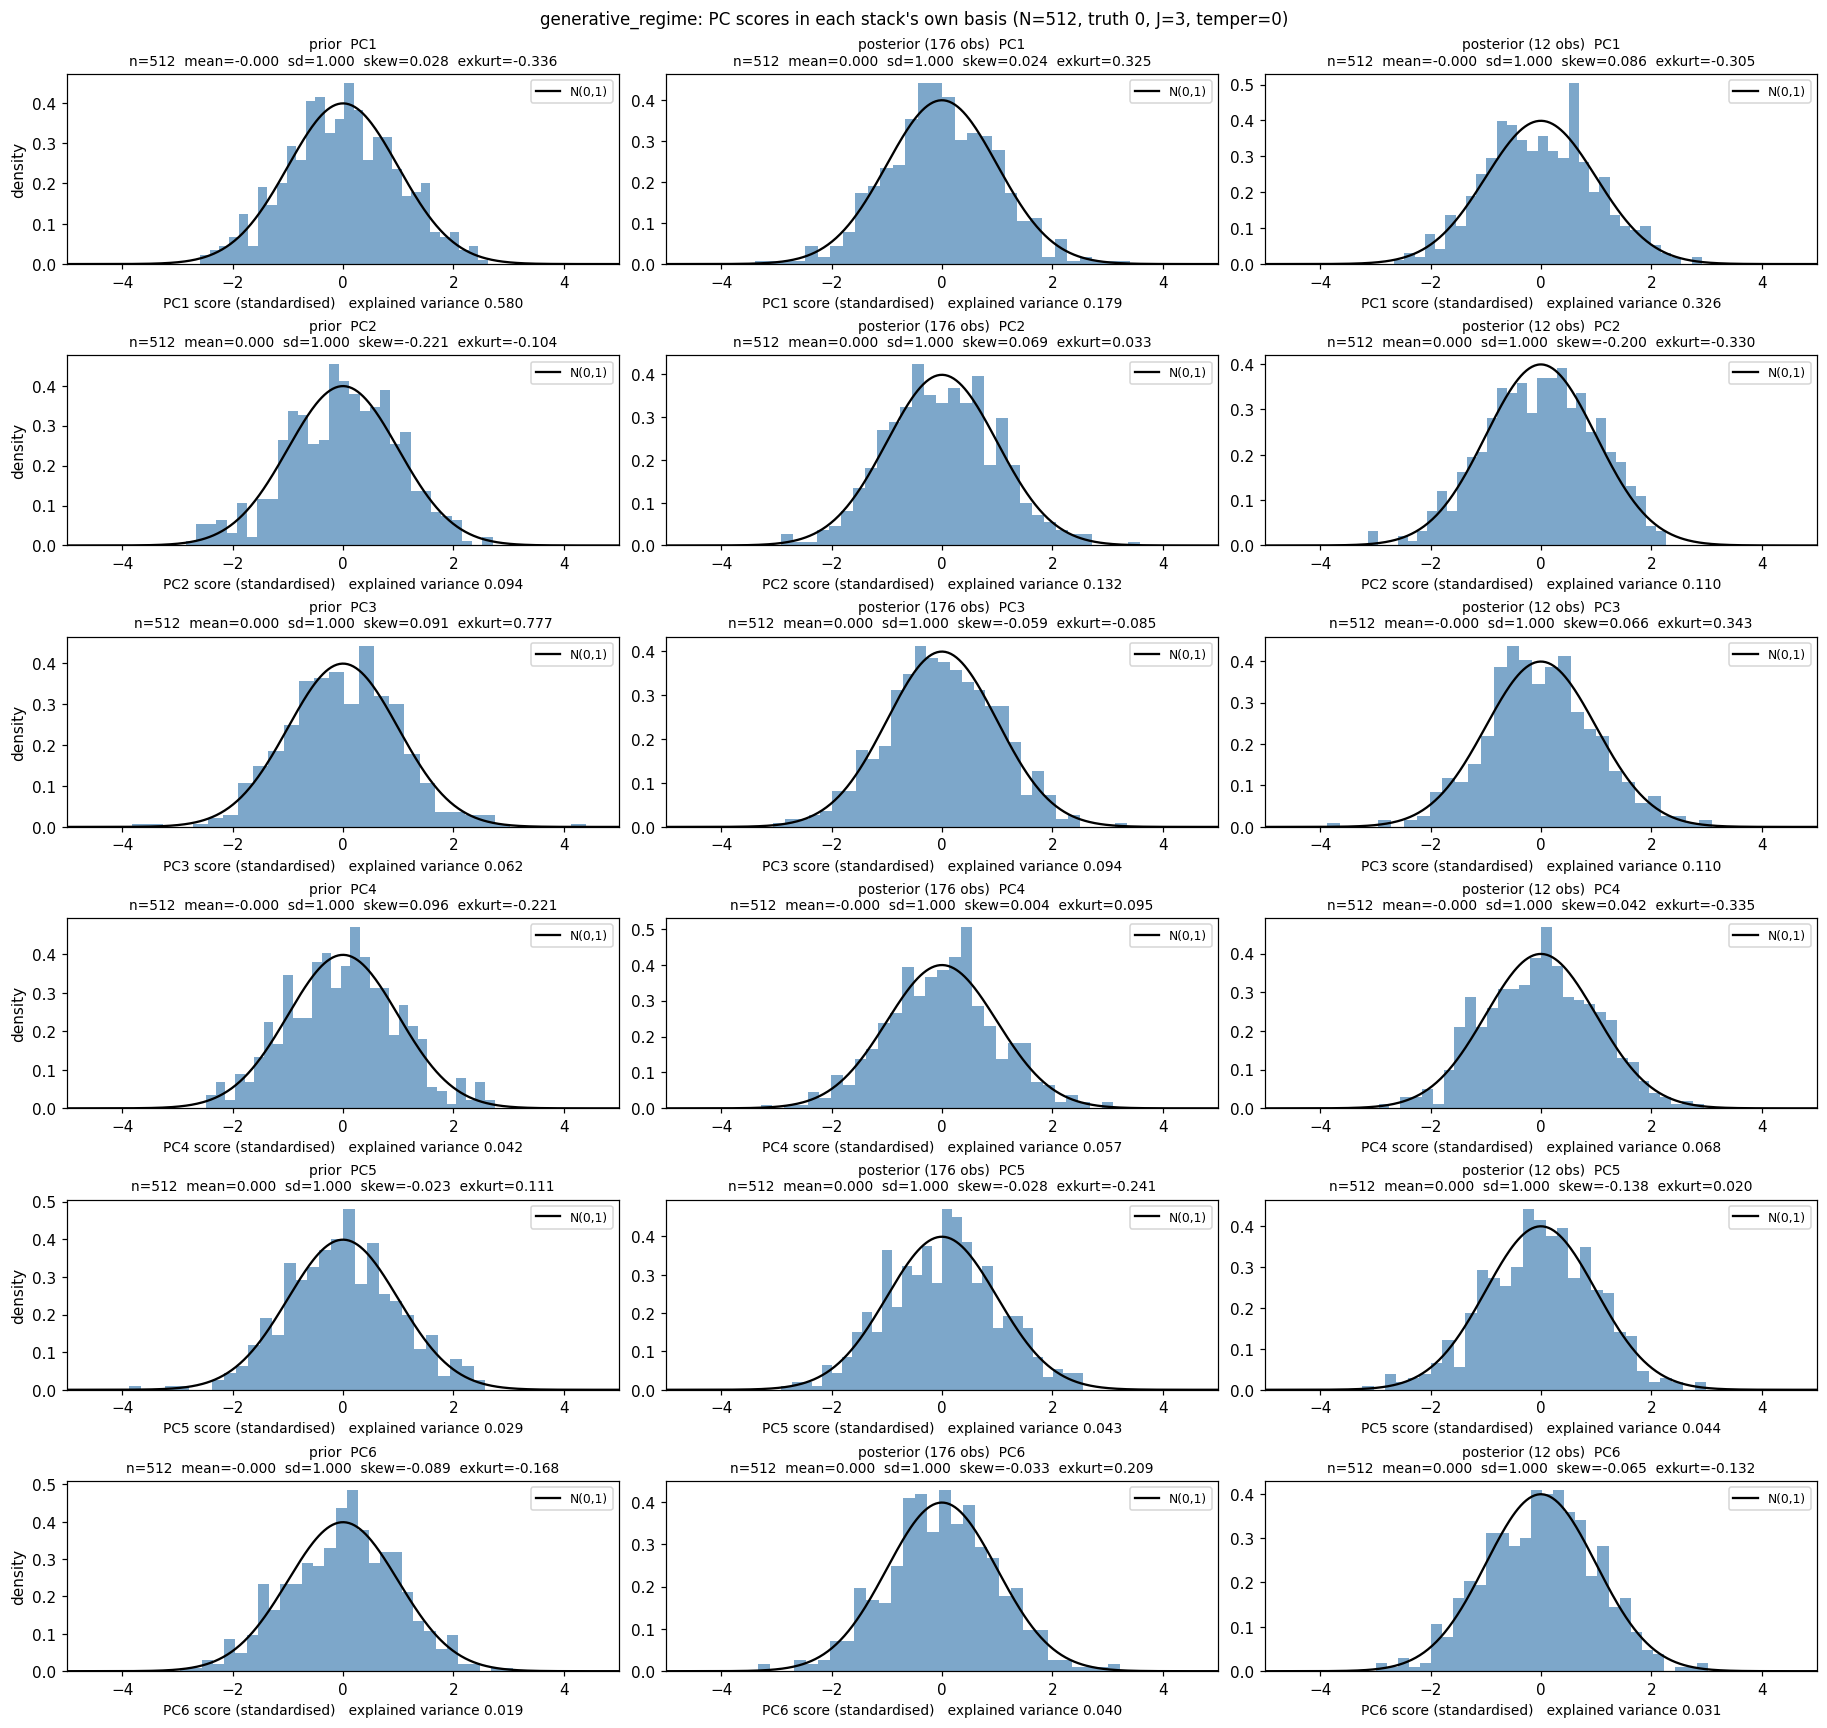

prior:
    PC1  evr 0.580 skew +0.03 exkurt -0.34
    PC2  evr 0.094 skew -0.22 exkurt -0.10
    PC3  evr 0.062 skew +0.09 exkurt +0.78
    PC4  evr 0.042 skew +0.10 exkurt -0.22
    PC5  evr 0.029 skew -0.02 exkurt +0.11
    PC6  evr 0.019 skew -0.09 exkurt -0.17
posterior (176 obs):
    PC1  evr 0.179 skew +0.02 exkurt +0.33
    PC2  evr 0.132 skew +0.07 exkurt +0.03
    PC3  evr 0.094 skew -0.06 exkurt -0.09
    PC4  evr 0.057 skew +0.00 exkurt +0.09
    PC5  evr 0.043 skew -0.03 exkurt -0.24
    PC6  evr 0.040 skew -0.03 exkurt +0.21
posterior (12 obs):
    PC1  evr 0.326 skew +0.09 exkurt -0.30
    PC2  evr 0.110 skew -0.20 exkurt -0.33
    PC3  evr 0.110 skew +0.07 exkurt +0.34
    PC4  evr 0.068 skew +0.04 exkurt -0.34
    PC5  evr 0.044 skew -0.14 exkurt +0.02
    PC6  evr 0.031 skew -0.06 exkurt -0.13


In [8]:
from paleoreco.eval.projection import orient_pcs, pca_scores, plot_pc_score_distributions

N_PC, N_PC_SAMPLES, PC_TRUTH = 6, 512, 0
_smp = RegimeSampler(MIX, RESIDUAL if sel["regime_temper"] > 0 else None,
                     b_scale=float(sel["b_scale"]), temper=float(sel["regime_temper"]),
                     inference="exact" if sel["regime_temper"] == 0 else "guided",
                     n_steps=N_STEPS, max_batch=MAX_BATCH, device=DEVICE)
_safe = F["safe"]
_geom, _yv = S["obs"](PC_TRUTH, TEST_SHAPE)

THIN = 12          # observations kept in the sparse panel, where the gain is largest
_rng = np.random.default_rng(0)
_keep = np.sort(_rng.permutation(len(_geom["gather"]))[:THIN])

RES_PC = {}
RES_PC["prior"] = orient_pcs(pca_scores(
    _smp.sample_prior(N_PC_SAMPLES, seed=5000)[:, :, _safe], N_PC))
RES_PC[f"posterior ({len(_geom['gather'])} obs)"] = orient_pcs(pca_scores(
    _smp.sample_posterior(_geom["gather"], _yv, _geom["sse"], float(sel["b_scale"]),
                          N_PC_SAMPLES, seed=6000)[:, :, _safe], N_PC))
RES_PC[f"posterior ({THIN} obs)"] = orient_pcs(pca_scores(
    _smp.sample_posterior(_geom["gather"][_keep], _yv[_keep], _geom["sse"][_keep],
                          float(sel["b_scale"]), N_PC_SAMPLES, seed=6001)[:, :, _safe], N_PC))

plot_pc_score_distributions(
    RES_PC, n_components=N_PC,
    title=(f"generative_regime: PC scores in each stack's own basis (N={N_PC_SAMPLES}, "
           f"truth {PC_TRUTH}, J={sel['regime_j']:g}, temper={sel['regime_temper']:g})"),
    save_path=str(FIG / "pc_marginals.png"))
plt.show()

from scipy import stats as _st
for label, res in RES_PC.items():
    sc = res["scores"]
    print(f"{label}:")
    for k in range(N_PC):
        print(f"    PC{k+1:<2} evr {res['explained_variance_ratio'][k]:.3f} "
              f"skew {_st.skew(sc[:, k]):+.2f} exkurt {_st.kurtosis(sc[:, k]):+.2f}")

### Which regime did the observations choose?

More direct than a projection: the posterior mixing weights per truth. This is the mechanism
itself, the observations resolving which regime the field is in, and it says plainly whether
the prior is being used as a mixture or collapsing to one component every time.

A truth where one weight is near 1 is a confident regime call. A truth with weight spread
across components is one the network cannot resolve, and it is there that a Gaussian
background has to average the regimes together while this posterior can keep them apart.
Thinning the network should move mass from the first case toward the second.

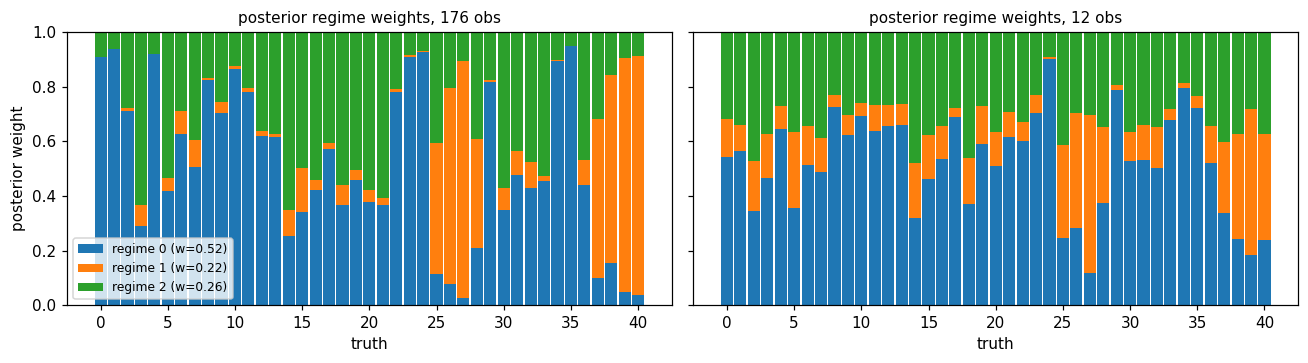

full network  : 15% of truths call one regime with weight > 0.9 | mean weight entropy 0.683 nats (0 = certain, 1.099 = no information)
12 obs        : 2% of truths call one regime with weight > 0.9 | mean weight entropy 0.905 nats (0 = certain, 1.099 = no information)


In [9]:
def weights_per_truth(keep=None):
    """Posterior mixing weight per truth, at the reported operating point."""
    out = np.zeros((T, MIX.n_regimes))
    for ti in range(T):
        geom, yv = S["obs"](ti, TEST_SHAPE)
        g, r, yy = geom["gather"], geom["sse"], yv
        if keep is not None:
            k = np.sort(np.random.default_rng(ti).permutation(len(g))[:keep])
            g, r, yy = g[k], r[k], yy[k]
        out[ti] = exact_posterior(MIX, g, r, yy, float(sel["b_scale"])).p
    return out


W_full, W_thin = weights_per_truth(), weights_per_truth(keep=THIN)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), sharey=True)
for ax, W, lab in ((axes[0], W_full, f"{len(_geom['gather'])} obs"),
                   (axes[1], W_thin, f"{THIN} obs")):
    bottom = np.zeros(T)
    for j in range(MIX.n_regimes):
        ax.bar(np.arange(T), W[:, j], bottom=bottom, width=0.9,
               label=f"regime {j} (w={MIX.w[j]:.2f})")
        bottom = bottom + W[:, j]
    ax.set_xlabel("truth"); ax.set_title(f"posterior regime weights, {lab}", fontsize=10)
    ax.set_ylim(0, 1)
axes[0].set_ylabel("posterior weight"); axes[0].legend(fontsize=8, loc="lower left")
fig.tight_layout(); fig.savefig(FIG / "regime_weights.png", bbox_inches="tight"); plt.show()

for W, lab in ((W_full, "full network"), (W_thin, f"{THIN} obs")):
    conf = (W.max(axis=1) > 0.9).mean()
    ent = -(W * np.log(np.clip(W, 1e-12, None))).sum(1).mean()
    print(f"{lab:14s}: {conf:.0%} of truths call one regime with weight > 0.9 | "
          f"mean weight entropy {ent:.3f} nats (0 = certain, "
          f"{np.log(MIX.n_regimes):.3f} = no information)")

## Reading

The cross-method comparison lives in `09_da_comparison`, which discovers
`outputs/da/generative_regime/` through its existing glob and reports this method at its own
selected operating point beside 3DVar, the latent methods and the other generative priors.

Three things to read here first, in order.

1. **The verification gates.** If gate 1 is not at machine precision, stop: the Gaussian part
   is wrong. If gate 3 shows the guided arm spending an appreciable fraction of a posterior
   standard deviation, the headline belongs to the exact arm and the guided one needs an
   asymptotically exact sampler rather than a finer schedule.
2. **The selected `(J, rho, temper)`.** `J = 1` or `temper = 0` are both legitimate outcomes
   of an honest selection, and both mean something specific about what did not work.
3. **The time-window control.** If cutting the prior into contiguous age windows scores like
   the state-space partition, the effect is the epoch and not the regime.

What this method claims and what it does not. It is a score-based prior whose score is
non-Gaussian at every noise level and whose analysis is a nonlinear function of the
observations, which no Gaussian background can be at any tuning. It is not a demonstration
that a trained network beats a well-chosen closed-form prior at this sample size; the temper
knob exists because that is an open question.